In [ ]:
!pip install torch
!pip install torch_geometric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.1 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.3 MB/s  0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.3 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 6.8 MB/s  0:00:00


   ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 1/2 [torch_geometric]

   ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 1/2 [torch_geometric]

   ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 1/2 [torch_geometric]

   ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 1/2 [torch_geometric]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torch_geometric]


In [ ]:
from torch_geometric.datasets import QM9

# 1) Download/load
dataset = QM9(root="data/QM9")

# 2) Basic checks
print("num graphs:", len(dataset))
print("num node features:", dataset.num_features)
print("num targets:", dataset.data.y.shape[-1])  # QM9 has 19 regression targets

# 3) Look at one molecule graph
g = dataset[0]
print(g)
print("x:", g.x.shape)                 # node features
print("edge_index:", g.edge_index.shape)
print("edge_attr:", g.edge_attr.shape)
print("y:", g.y.shape)                 # usually [1, 19]

Extracting data/QM9/raw/qm9_v3.zip


Processing...


Using a pre-processed version of the dataset. Please install 'rdkit' to alternatively process the raw data.


Done!


num graphs: 130831


...

Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], idx=[1], name='gdb_1', z=[5])


x: torch.Size([5, 11])


edge_index: torch.Size([2, 8])


edge_attr: torch.Size([8, 4])


y: torch.Size([1, 19])


Any bg about this dataset wtf are we looking at?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

QM9 is a standard benchmark dataset in graph machine learning and computational chemistry. Here's the quick rundown:

- **~130K small organic molecules** made up of H, C, N, O, F atoms (up to 9 heavy atoms)
- Each molecule is represented as a **graph**: atoms are nodes, bonds are edges
- **Node features** (11-dim): one-hot encoding of atom type, plus properties like aromaticity, hybridization, etc.
- **Edge features** (4-dim): bond type (single/double/triple/aromatic) encoded one-hot
- **`pos`**: actual 3D coordinates of each atom — this is what makes QM9 interesting for geometric GNNs like EGNN
- **19 regression targets**: quantum-mechanical properties computed via DFT (density functional theory) — things like dipole moment, internal energy, HOMO/LUMO energies, zero-point vibrational energy, heat capacity, etc.

So essentially: given a molecule's graph structure (and optionally its 3D geometry), predict its physical/chemical properties. The 3D coordinates are what models like EGNN are designed to exploit — they're **E(3)-equivariant**, meaning they respect rotational, translational, and reflection symmetry of 3D space.

What are you working on — analyzing EGNN's performance on this dataset?

Yes, Im replicating QM9 benchmark using egnn

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Nice! The EGNN paper (Satorras, Hoogeboom, Welling, 2021) benchmarks on QM9 with the standard split: 110K train, 10K validation, 10K test (the remaining ~831 are unused).

A few things that are standard in the EGNN QM9 setup:

- **Only the mean and std of the training set targets are used for normalization** — important for fair comparison
- **3D coordinates (`pos`)** are the key input that EGNN uses (along with node features), unlike standard GNNs that only use graph topology
- The 19 targets are reported individually with **MAE** as the metric
- They report both the **mean MAE** across targets and per-target MAE

What stage are you at — do you have the EGNN model implementation already, or are you starting from scratch?

no i want to explore and understand this dataset frist

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Good call — understanding the data first makes everything downstream clearer.

Here are a few angles you could explore:

1. **What do the 19 targets actually represent?** (e.g., which physical/chemical properties)
2. **What do the node features encode?** (the 11-dim feature vector — what each column means)
3. **Molecule statistics** — how many atoms per molecule, bond types distribution, etc.
4. **Target distributions** — ranges, skewness, outliers
5. **3D coordinate structure** — what do the molecules actually look like in space

Which of these interests you most to start with?

lets start with targets

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Here are the 19 targets, grouped logically:

**Electronic properties:**
1. **μ** — dipole moment
2. **α** — isotropic polarizability
3. **ε_HOMO** — highest occupied molecular orbital energy
4. **ε_LUMO** — lowest unoccupied molecular orbital energy
5. **Δε** — HOMO-LUMO gap (difference of 3 and 4)

**Energetic properties:**
6. **⟨R²⟩** — electronic spatial extent
7. **ZPVE** — zero-point vibrational energy
8. **U₀** — internal energy at 0K
9. **U** — internal energy at 298K
10. **H** — enthalpy at 298K
11. **G** — free energy at 298K
12. **c_v** — heat capacity at 298K

**Atomization energies** (energy to break molecule into individual atoms):
13. **U₀_ATOM** — atomization energy at 0K
14. **U_ATOM** — atomization energy at 298K
15. **H_ATOM** — atomization enthalpy at 298K
16. **G_ATOM** — atomization free energy at 298K

**Vibrational frequencies:**
17. **A** — highest normal mode frequency
18. **B** — second highest
19. **C** — third highest

All computed via DFT (quantum mechanical simulation). Want to look at the distributions of some of these, or dig into the node features next?

should i put the paper in reference fyr best way to do in solveit?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Yes, having the paper handy is a great idea. A couple of options in solveit:

1. **Add a note message** with the paper link and citation info — easy to reference anytime
2. **If it's a PDF**, you can upload it as media in a message, and I'll be able to read it directly in context
3. **If it's online**, I can use `read_url` to pull content from the paper's webpage (e.g., arXiv abstract page)

The PDF upload is the most useful since I can actually read the content and help you compare it against your implementation. ArXiv link is https://arxiv.org/abs/2102.09844 if you want to grab the PDF from there.

Which approach works for you?

it should be in this folder itself

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Let me check what's in the current folder:



<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;fd(&#x27;.&#x27;, pattern=&#x27;pdf&#x27;) + fd(&#x27;.&#x27;, pattern…&quot;)→&quot;[&#x27;EGNN.pdf&#x27;]&quot;</code></summary>

```json
{
  "id": "chatcmpl-tool-ae8d0ec94da423d3",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "fd('.', pattern='pdf') + fd('.', pattern='egnn', glob='*.pdf')"
    }
  },
  "result": "['EGNN.pdf']"
}
```

</details>

There's an `EGNN.pdf` right here in the folder. You can add it to a message in the dialog so I can read it — just create a new message and upload the PDF as media. That way I'll have direct access to the paper content alongside our analysis.

Alternatively, if you want me to try reading it right now via Python, I could attempt to extract text from it. Want me to try that?

just give me code to give as ctxt


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
import subprocess, sys

# PyMuPDF is a good lightweight PDF text extractor
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "PyMuPDF"])

import fitz  # PyMuPDF

doc = fitz.open("EGNN.pdf")
text = "\n\n".join(page.get_text() for page in doc)
print(len(text), "chars")
print(text[:2000])
```

Run that, and then I'll be able to see the extracted text in the output. If it's too long we can narrow it down to specific sections.

In [ ]:
import subprocess, sys

# PyMuPDF is a good lightweight PDF text extractor
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "PyMuPDF"])

import fitz  # PyMuPDF

doc = fitz.open("EGNN.pdf")
text = "\n\n".join(page.get_text() for page in doc)
print(len(text), "chars")
print(text)


65381 chars


E(n) Equivariant Graph Neural Networks
Victor Garcia Satorras 1 Emiel Hoogeboom 1 Max Welling 1
Abstract
This paper introduces a new model to learn graph
neural networks equivariant to rotations, transla-
tions, reﬂections and permutations called E(n)-
Equivariant Graph Neural Networks (EGNNs). In
contrast with existing methods, our work does not
require computationally expensive higher-order
representations in intermediate layers while it
still achieves competitive or better performance.
In addition, whereas existing methods are lim-
ited to equivariance on 3 dimensional spaces,
our model is easily scaled to higher-dimensional
spaces. We demonstrate the effectiveness of our
method on dynamical systems modelling, repre-
sentation learning in graph autoencoders and pre-
dicting molecular properties.
1. Introduction
Although deep learning has largely replaced hand-crafted
features, many advances are critically dependent on induc-
tive biases in deep neural networks. An effective method t

cool now tell me for the paper what all targets and runs were there


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

From the paper (Section 5.3 + Appendix C.3), here's the full breakdown:

**12 targets reported** (out of QM9's 19 total — they only use a subset):

| Target | Property | Units |
|--------|----------|-------|
| α | Isotropic polarizability | bohr³ |
| Δε | HOMO-LUMO gap | meV |
| ε_HOMO | HOMO energy | meV |
| ε_LUMO | LUMO energy | meV |
| µ | Dipole moment | Debye |
| Cν | Heat capacity | cal/mol·K |
| G | Free energy (298K) | meV |
| H | Enthalpy (298K) | meV |
| R² | Electronic spatial extent | bohr³ |
| U | Internal energy (298K) | meV |
| U₀ | Internal energy (0K) | meV |
| ZPVE | Zero-point vibrational energy | meV |

**Training setup per target:**
- Each property trained **individually** (12 separate runs)
- **1,000 epochs** each
- Batch size 96, Adam optimizer, weight decay 10⁻¹⁶
- Cosine LR decay, starting at **5×10⁻⁴** (but **10⁻³** for HOMO, LUMO, and Gap)
- 7 EGNN layers, 128 hidden features
- Normalization: subtract mean, divide by Mean Absolute Deviation (MAD)
- Sum pooling → 2-layer MLP for output

**Data split** (from Anderson et al. / Cormorant):
- 100K train, 18K validation, 13K test

So that's **12 separate training runs**, one per property. The other 3 experiments in the paper (N-body, Graph Autoencoder) are separate from the QM9 benchmark.

lets use pandas and do a describe on the 12 fields. before that stor the name of 12 fields in a list.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Here's code to do that:

```python
import pandas as pd
import torch

# The 12 targets used in the EGNN paper (QM9 indices 0-11)
target_names = [
    'mu',       # dipole moment
    'alpha',    # polarizability
    'homo',     # HOMO energy
    'lumo',     # LUMO energy
    'gap',      # HOMO-LUMO gap
    'r2',       # electronic spatial extent
    'zpve',     # zero-point vibrational energy
    'u0',       # internal energy at 0K
    'u',        # internal energy at 298K
    'h',        # enthalpy at 298K
    'g',        # free energy at 298K
    'cv',       # heat capacity at 298K
]

# Stack all targets into a tensor and convert to DataFrame
y_all = torch.cat([dataset[i].y for i in range(len(dataset))], dim=0).numpy()
df = pd.DataFrame(y_all[:, :12], columns=target_names)

print(df.describe())
```

This extracts the first 12 of QM9's 19 targets (indices 0–11), which are exactly the ones the paper reports on. The remaining 7 (atomization energies and vibrational frequencies) aren't used.

In [ ]:
import pandas as pd
import torch

# The 12 targets used in the EGNN paper (QM9 indices 0-11)
target_names = [
    'mu',       # dipole moment
    'alpha',    # polarizability
    'homo',     # HOMO energy
    'lumo',     # LUMO energy
    'gap',      # HOMO-LUMO gap
    'r2',       # electronic spatial extent
    'zpve',     # zero-point vibrational energy
    'u0',       # internal energy at 0K
    'u',        # internal energy at 298K
    'h',        # enthalpy at 298K
    'g',        # free energy at 298K
    'cv',       # heat capacity at 298K
]

# Stack all targets into a tensor and convert to DataFrame
y_all = torch.cat([dataset[i].y for i in range(len(dataset))], dim=0).numpy()
df = pd.DataFrame(y_all[:, :12], columns=target_names)

print(df.describe())


                  mu          alpha           homo           lumo  \
count  130831.000000  130831.000000  130831.000000  130831.000000   
mean        2.672953      75.281181      -6.536453       0.322044   
std         1.503479       8.173831       0.597741       1.274855   
min         0.000000       6.310000     -11.662800      -4.761992   
25%         1.577800      70.480003      -6.873596      -0.634025   
50%         2.475300      75.599998      -6.560665       0.342863   
75%         3.596350      80.610001      -6.228686       1.385060   
max        29.556400     196.619995      -2.767398       5.265403   

                 gap             r2           zpve             u0  \
count  130831.000000  130831.000000  130831.000000  130831.000000   
mean        6.858492    1189.410522       4.056937  -11178.966797   
std         1.284169     280.478149       0.901723    1085.578735   
min         0.669400      19.000200       0.434049  -19444.386719   
25%         5.904871    1017.4312

Can you give me one-line explanation of what all these targets mean and why are the ranges such as shown above? 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Here's each target with a quick explanation and why the ranges look the way they do:

1. **μ (mu)** — Dipole moment (Debye). Measures charge separation polarity; 0 means perfectly symmetric, large values mean very polar molecules. Max 29.6 is unusually polar.

2. **α (alpha)** — Isotropic polarizability (bohr³). How easily the electron cloud distorts under an electric field; bigger molecules → larger α, hence the ~6–197 range centered around 75.

3. **ε_HOMO (homo)** — Highest occupied molecular orbital energy (eV). How tightly the top electrons are bound; negative because energies are referenced to vacuum level. More negative = harder to remove an electron.

4. **ε_LUMO (lumo)** — Lowest unoccupied molecular orbital energy (eV). Where the next electron would go; ranges from -4.8 to +5.3, positive means it's energetically unfavorable to add an electron.

5. **Δε (gap)** — HOMO-LUMO gap (eV). Energy needed to excite an electron; small gap = reactive/absorbs visible light, large gap = stable/insulator-like. Range 0.67–16.9.

6. **⟨R²⟩ (r2)** — Electronic spatial extent (bohr²). How spread out the electron cloud is; scales with molecule size, hence large values (~19–3375).

7. **ZPVE (zpve)** — Zero-point vibrational energy (eV). Residual quantum vibration energy at 0K; more atoms/bonds → higher ZPVE. Range 0.43–7.45.

8. **U₀ (u0)** — Internal energy at 0K (eV). Total electronic + nuclear energy; very negative because bond formation releases energy. Range -19444 to -1101.

9. **U (u)** — Internal energy at 298K (eV). Same as U₀ plus thermal corrections; nearly identical to U₀ (differences are tiny, ~0.23 meV on average).

10. **H (h)** — Enthalpy at 298K (eV). U + PV; for solids/molecules PV term is negligible, so nearly identical to U.

11. **G (g)** — Free energy at 298K (eV). H - TS; slightly lower than H due to the entropy (TS) subtraction. Notice mean is ~1.2 meV below H.

12. **Cv (cv)** — Heat capacity at 298K (cal/mol·K). How much energy to raise temperature; depends on number of vibrational modes, so scales with molecule size. Range 6–47.

The key pattern: U₀, U, H, G are all nearly identical because they differ only by small thermal/entropy corrections at 298K for these small molecules. The energy targets are large and negative (bond energies), while electronic properties like HOMO/LUMO/gap are on the eV scale.

fuck im too dum to get thi


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

You're not dumb at all — this is dense quantum chemistry stuff that takes time to absorb. Most people don't learn this until grad school.

The good news: **you don't need to deeply understand all 12 targets to use them**. For the EGNN benchmark, you just need to know:

- Each molecule has 12 numbers to predict
- Your model learns to predict them from the 3D structure
- You measure error with MAE (mean absolute error)

That's it. The physics behind what each number *means* is helpful context but not required to run the experiment.

What part is feeling the most confusing? We can slow way down and tackle just one thing at a time.

start one prop at a time and ill give you back what i understood

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Let's start with **μ (dipole moment)**.

Imagine a molecule is like a magnet. Some molecules have a "positive end" and a "negative end" because the electrons aren't evenly distributed. The **dipole moment** measures *how lopsided* the charge is.

- **0** = perfectly symmetric, no polarity (like CO₂)
- **High** = very lopsided, one side is much more negative (like water)

Think of it as: "how much would this molecule get pulled by an electric field?"

What makes sense or doesn't about this one?

basically ow charge is ditributed in space i remember it was charget tme displacemtn

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Exactly! You're remembering it right — it's literally charge × distance. In physics terms:

$$\mu = \sum_i q_i \cdot \mathbf{r}_i$$

where $q_i$ is each charge and $\mathbf{r}_i$ is its position relative to some center point.

So if positive and negative charges are spread out evenly (cancel out), μ = 0. If they're lopsided, you get a nonzero dipole.

You got it. Ready for the next one — **α (polarizability)**?

ok i remember its something to do with glasses where the waves are rotated such that it block uv

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Close! You're thinking of **polarization of light** (like polarized sunglasses). That's related but not quite the same thing.

**Polarizability (α)** is about the molecule, not the light. Here's the idea:

Imagine an electron cloud around a molecule like a squishy blob. If you apply an electric field, the blob **stretches** — the electrons get pulled one way, the nuclei stay put. 

**α measures how easily that blob stretches.**

- Big, fluffy electron clouds (large molecules) → easy to stretch → high α
- Small, tightly held electrons → hard to stretch → low α

That's why α ranges from ~6 (tiny molecules) to ~197 (big ones).

The connection to what you're remembering: polarized glasses work *because* materials with high polarizability interact with light differently — so your intuition is actually pointing in the right direction!

Make sense?

Basically, it's how the shape of the molecule is changed when an electric field is applied to it. 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Exactly right! The electron cloud shape changes (distorts) under an electric field, and α tells you how much. 

Ready for the next one — **ε_HOMO**?

yes

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

**ε_HOMO** — think of a molecule's electrons sitting in energy "levels," like floors in a building. Electrons fill from the bottom up.

**HOMO = the highest floor that actually has an electron in it.** (Highest Occupied Molecular Orbital.)

The energy of that floor tells you:
- **Very negative** = electrons are sitting deep down, tightly bound → hard to remove them
- **Less negative** = electrons are up high, loosely bound → easy to remove (more reactive)

That's why it ranges from -11.7 to -2.8 eV. It's always negative because you'd need to *add* energy to rip that electron away.

Think of it as: **"how hard is it to steal an electron from this molecule?"**

Does that click?

ok so more the negative higher the floor it is? and more difficult to pull out ?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Yes, exactly! Think of HOMO as the "top floor" where electrons live. The more negative it is, the deeper down that floor sits — like electrons are in a **deeper well**.

- Very negative HOMO (like -11.7) → electrons are held tightly, hard to remove (stable molecule)
- Less negative HOMO (like -2.8) → electrons are loose, easy to pull out (reactive molecule)

It's basically "how hard is it to steal an electron from this molecule?"

You're nailing these. Next up — **ε_LUMO**?

lowest unoccupied molecular orbital?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Exactly! If HOMO is the top floor where electrons *live*, LUMO is the **first empty floor** above it — where the next electron would go if you tried to add one.

- Low (negative) LUMO → molecule *wants* to accept an electron (empty room ready and waiting)
- High (positive) LUMO → molecule *doesn't want* an electron (you'd have to push it in uphill)

So: **HOMO = how hard to take an electron, LUMO = how hard to give one.**

Ready for **gap (Δε)**?

so it is like the terrace on top of penthouse

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Exactly! LUMO is the terrace right above the penthouse (HOMO). Perfect analogy.

Now **gap (Δε)** — it's literally just the distance between the penthouse and the terrace:

$$\text{gap} = \text{LUMO} - \text{HOMO}$$

- Small gap → easy to jump from penthouse to terrace → molecule is reactive, absorbs light easily
- Large gap → big jump needed → molecule is stable, needs lots of energy to excite

Think of it as: "how much energy to kick an electron up one floor?"

btw how to use solveit to create quarto like blogs?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

That's a bit of a side quest from QM9, but happy to help!

Quarto actually renders `.ipynb` files natively — and since solveit dialogs *are* `.ipynb` files, you could write your blog content as notes in a solveit dialog and then render it with Quarto directly:

```bash
quarto render mydialog.ipynb --to html
```

For a full blog setup, you'd want:
- A Quarto project (`_quarto.yml` with `type: website`)
- Each post as a separate solveit dialog/notebook
- Quarto handles the templating, navbar, listings, etc.

Want me to look into what's available in this environment for Quarto, or shall we get back to the QM9 targets?

got it how mch energy for penthouse owner to go to terrace

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Exactly! That's the gap in one sentence. 

Ready for **R² (electronic spatial extent)**?

lemme gas square of radius of electron cloud?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Spot on! It's literally the mean squared distance of electrons from the center of the molecule:

$$\langle R^2 \rangle = \sum_i q_i \cdot |\mathbf{r}_i|^2$$

So it's basically "how spread out are the electrons?" — bigger molecule, bigger number. That's why it ranges from ~19 (tiny) to ~3375 (big).

Next up — **ZPVE (zero-point vibrational energy)**?

this one is tricky... how much vibration at 0K?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Yes, exactly! Even at absolute zero temperature, atoms in a molecule still **jiggle** — they can't sit perfectly still. That's a quantum mechanics thing (Heisenberg uncertainty — you can't have zero position and zero momentum at the same time).

ZPVE is the **energy of that unavoidable jiggling**.

- More atoms and bonds → more ways to vibrate → higher ZPVE
- That's why it ranges from ~0.4 (tiny molecules) to ~7.5 (bigger ones)

Think of it as: "the minimum energy a molecule can never get rid of."

Ready for the next group — **U₀, U, H, G**?

yes and always talk about value ranges when you are defining

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

These four are all closely related — they're all measures of the molecule's **total energy**, just at different conditions:

**U₀ (internal energy at 0K)** — The base energy of the molecule: all the bond energies, electronic energies, plus ZPVE. No thermal energy at all. Range: -19,444 to -1,101 eV. Very negative because forming bonds releases energy.

**U (internal energy at 298K)** — Same as U₀, but add the extra thermal vibration energy from room temperature. Almost identical to U₀ — the difference is tiny (less than 1 eV).

**H (enthalpy at 298K)** — U plus a small PV (pressure × volume) correction. For molecules this is basically the same as U. Range nearly identical.

**G (free energy at 298K)** — H minus TS (entropy × temperature). This is the "useful" energy — what actually drives chemical reactions. Slightly lower than H because you subtract the entropy term. Notice the mean is ~1.2 meV below H.

The key takeaway: **U₀, U, H, G are almost the same numbers** because for small molecules the thermal and entropy corrections are tiny compared to the total bond energy.

Want to do the last one — **Cv**?

dont get free energy and enthalpy and wtf is entropy

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Let's take it slow, one concept at a time.

**Entropy (S)** — Imagine your room. If all your stuff is neatly organized, that's low entropy. If everything is scattered everywhere, that's high entropy. In molecules, it's the same idea — how many ways can the atoms arrange themselves (vibrate, rotate, jiggle) and still be the same molecule?

- Simple, rigid molecule → few ways to move → low entropy
- Complex, floppy molecule → many ways to move → high entropy

Entropy is basically a measure of **disorder** or **how many ways things can wiggle around**.

Does that concept make sense before we build on it?

ok

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

**Enthalpy (H)** — Start with internal energy U (all the bond energies + thermal jiggling). Now add a tiny bit extra because the molecule takes up space (PV — pressure × volume). 

For molecules in QM9, this PV term is basically nothing, so H ≈ U. That's why their ranges are nearly identical (-19,444 to -1,101).

Think of it as: "total energy + the cost of occupying space."

Good so far?

good

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

**Free energy (G)** — Take enthalpy H, then subtract the "wasted" energy from all that disorder. That's $G = H - TS$.

Think of it like this: you have total energy H, but not all of it is *useful* — some of it is tied up in the random jiggling (entropy × temperature = TS). G is what's left — the **energy that can actually do something**, like drive a chemical reaction.

- More entropy (more disorder) → more energy wasted → G is lower than H
- That's why in the data, G's mean is ~1.2 meV below H — small but real

It's basically: "useful energy = total energy - wasted jiggling energy."

Does that click?

ok chalo fast

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

**Cv (heat capacity)** — How much energy you need to pump in to raise the molecule's temperature by 1 degree. More atoms → more ways to vibrate → more energy needed. Range: 6–47 cal/mol·K.

That's all 12 done! You got through them. Ready to move on to the next part of your QM9 exploration?

ya let me see the features all togeher in one row

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Here's code to pull all the node features for the first molecule into one DataFrame row:

```python
import pandas as pd

g = dataset[0]
feat_names = ['H','C','N','O','F',' aromatic','hybrid sp','hybrid sp2','hybrid sp3','#H','in_ring']

df_feat = pd.DataFrame(g.x.numpy(), columns=feat_names)
df_feat.insert(0, 'atom_idx', range(len(df_feat)))
df_feat
```

This shows the 11 feature columns for each of the 5 atoms in the first molecule (gdb_1). Want to run it and see what comes up?

In [ ]:
import pandas as pd

g = dataset[0]
feat_names = ['H','C','N','O','F',' aromatic','hybrid sp','hybrid sp2','hybrid sp3','#H','in_ring']

df_feat = pd.DataFrame(g.x.numpy(), columns=feat_names)
df_feat.insert(0, 'atom_idx', range(len(df_feat)))
df_feat


,atom_idx,H,C,N,O,F,aromatic,hybrid sp,hybrid sp2,hybrid sp3,#H,in_ring
0,0,0.0,1.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,4.0
1,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


What's going on here?
The first one I understand is the atom ID. The few rows are about one-hot encoding whether that molecule exists or not.
- Aromatic: I have no idea. I guess sp and sp2 are some kind of orbital.
- In ring: I have no idea, maybe it's in a ring or not.
I don't know. It was 4 for entering. This is quite tricky to read.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Good observations! But my column names were wrong — sorry about that. Let me fix them based on what we actually see:

**Columns 0–4: Atom type** — one-hot, exactly as you said. Atom 0 is carbon (C=1), atoms 1–4 are hydrogen (H=1). This molecule is **CH₄ (methane)**!

**Column 5 (I labeled "aromatic"):** This is actually **atomic number**. Carbon=6, Hydrogen=1. That's why C shows 6 and H shows 1.

**Columns 6–8: Aromatic + hybridization** — These tell you about the bonding. sp, sp², sp³ describe how orbitals mix:
- sp³ = 4 simple bonds (like methane's carbon)
- sp² = 3 bonds, one double bond (like in benzene)
- sp = 2 bonds, triple bonds

**Column 9: # of H atoms on this atom** — All 0 here, which seems odd for CH₄...

**Column 10 (I labeled "in_ring"):** This looks like it's actually the **number of H neighbors** — carbon has 4 (it's bonded to 4 H atoms), each H has 0.

Want me to pull up the actual PyG QM9 source to confirm the exact feature definitions?

Where does it say we are looking at CH4? 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Two clues:

1. **The atom types** — Row 0 has C=1 (one carbon), rows 1–4 all have H=1 (four hydrogens). That's 1 carbon + 4 hydrogens = CH₄.

2. **The name field** — When we first printed `g = dataset[0]` earlier, the output showed `name='gdb_1'`. QM9 molecules are indexed in the GDB database, and gdb_1 is methane (CH₄), the simplest molecule in the dataset.

You can also verify by checking `g.z` (atomic numbers) — it should show `[6, 1, 1, 1, 1]` for carbon + 4 hydrogens.

Now let's look at another example in the same nice pandas format

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Try a molecule with more interesting atoms — pick something with N or O. Here's a quick way to find one:

```python
# Find first molecule containing nitrogen
for i in range(len(dataset)):
    if dataset[i].z.tolist().__contains__(7):  # atomic number 7 = nitrogen
        print(f"index {i}, atoms: {dataset[i].z.tolist()}, name: {dataset[i].name}")
        break
```

Run that and we'll display it in the same format.

In [ ]:
# Find first molecule containing nitrogen
for i in range(len(dataset)):
    if dataset[i].z.tolist().__contains__(7):  # atomic number 7 = nitrogen
        print(f"index {i}, atoms: {dataset[i].z.tolist()}, name: {dataset[i].name}")
        break


index 1, atoms: [7, 1, 1, 1], name: gdb_2


lol wut where is pandas

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Ha, fair enough — that was just the search step. Now display it in the same pandas format:

```python
g = dataset[1]
df_feat = pd.DataFrame(g.x.numpy(), columns=feat_names)
df_feat.insert(0, 'atom_idx', range(len(df_feat)))
df_feat
```

This is NH₃ (ammonia) — 1 nitrogen + 3 hydrogens.

In [ ]:
g = dataset[1]
df_feat = pd.DataFrame(g.x.numpy(), columns=feat_names)
df_feat.insert(0, 'atom_idx', range(len(df_feat)))
df_feat


,atom_idx,H,C,N,O,F,aromatic,hybrid sp,hybrid sp2,hybrid sp3,#H,in_ring
0,0,0.0,0.0,1.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,3.0
1,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


ok so 2h 1n and 1c so weird and what is in_ring here

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Actually it's **1 nitrogen + 3 hydrogens** — no carbon! That's NH₃ (ammonia). You can see N=1 for row 0, and H=1 for rows 1–3.

Now look at the "in_ring" column: nitrogen has **3**, each hydrogen has **0**. This matches the pattern from CH₄ where carbon had 4 and hydrogens had 0. So this column is actually the **number of hydrogen atoms bonded to this atom**:

- Nitrogen in NH₃ → bonded to 3 H's → 3
- Each H → bonded to 0 H's → 0
- Carbon in CH₄ → bonded to 4 H's → 4

My original "in_ring" label was wrong — it's really **number of H neighbors**. Want to check a bigger molecule to confirm?

lol get legit labels

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Let me check the actual PyG QM9 source to get the real feature names:



<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;import inspect\nfrom torch_geometric.data…&quot;)→&quot;[&#x27;num_edge_features&#x27;, &#x27;num_features&#x27;, &#x27;n…&quot;</code></summary>

```json
{
  "id": "chatcmpl-tool-8d5ddab20b7916cc",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "import inspect\nfrom torch_geometric.datasets import QM9\nprint(inspect.getsource(QM9.raw_file_names.__func__) if hasattr(QM9.raw_file_names, '__func__') else \"\")\n# Also check if there's a feature names attribute\nprint([a for a in dir(QM9) if 'feat' in a.lower() or 'name' in a.lower() or 'desc' in a.lower()])"
    }
  },
  "result": "['num_edge_features', 'num_features', 'num_node_features', 'processed_file_names', 'raw_file_names']"
}
```

</details>





<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;src = inspect.getsource(QM9)\n# Find wher…&quot;)→&quot;   skip = [int(x.split()[0]) - 1 for x i…&quot;</code></summary>

```json
{
  "id": "chatcmpl-tool-8e9e3a721e812f74",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "src = inspect.getsource(QM9)\n# Find where x features are defined\nidx = src.find('x =')\nprint(src[max(0,idx-500):idx+500])"
    }
  },
  "result": "   skip = [int(x.split()[0]) - 1 for x in f.read().split('\\n')[9:-2]]\n\n        suppl = Chem.SDMolSupplier(self.raw_paths[0], removeHs=False,\n                                   sanitize=False)\n\n        data_list = []\n        for i, mol in enumerate(tqdm(suppl)):\n            if i in skip:\n                continue\n\n            N = mol.GetNumAtoms()\n\n            conf = mol.GetConformer()\n            pos = conf.GetPositions()\n            pos = torch.tensor(pos, dtype=torch.float)\n\n            type_idx = []\n            atomic_number = []\n            aromatic = []\n            sp = []\n            sp2 = []\n            sp3 = []\n            num_hs = []\n            for atom in mol.GetAtoms():\n                type_idx.append(types[atom.GetSymbol()])\n                atomic_number.append(atom.GetAtomicNum())\n                aromatic.append(1 if atom.GetIsAromatic() else 0)\n                hybridization = atom.GetHybridization()\n                sp.append(1 if hybridization == HybridizationType.SP else"
}
```

</details>





<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;idx2 = src.find(&#x27;num_hs = []&#x27;, idx)\nprin…&quot;)→&quot;            for atom in mol.GetAtoms():\n…&quot;</code></summary>

```json
{
  "id": "chatcmpl-tool-8ad3f3381cb88eb1",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "idx2 = src.find('num_hs = []', idx)\nprint(src[idx2+12:idx2+800])"
    }
  },
  "result": "            for atom in mol.GetAtoms():\n                type_idx.append(types[atom.GetSymbol()])\n                atomic_number.append(atom.GetAtomicNum())\n                aromatic.append(1 if atom.GetIsAromatic() else 0)\n                hybridization = atom.GetHybridization()\n                sp.append(1 if hybridization == HybridizationType.SP else 0)\n                sp2.append(1 if hybridization == HybridizationType.SP2 else 0)\n                sp3.append(1 if hybridization == HybridizationType.SP3 else 0)\n\n            z = torch.tensor(atomic_number, dtype=torch.long)\n\n            rows, cols, edge_types = [], [], []\n            for bond in mol.GetBonds():\n                start, end = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()\n                rows += [start, end]"
}
```

</details>





<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;# Find where x is assembled\nidx3 = src.f…&quot;)→&quot;x = torch.tensor([rows, cols], dtype=tor…&quot;</code></summary>

```json
{
  "id": "chatcmpl-tool-a75f4b29f695622c",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "# Find where x is assembled\nidx3 = src.find('x = ', idx2)\nprint(src[idx3:idx3+500])"
    }
  },
  "result": "x = torch.tensor([rows, cols], dtype=torch.long)\n            edge_type = torch.tensor(edge_types, dtype=torch.long)\n            edge_attr = one_hot(edge_type, num_classes=len(bonds))\n\n            perm = (edge_index[0] * N + edge_index[1]).argsort()\n            edge_index = edge_index[:, perm]\n            edge_type = edge_type[perm]\n            edge_attr = edge_attr[perm]\n\n            row, col = edge_index\n            hs = (z == 1).to(torch.float)\n            num_hs = scatter(hs[row], col, dim_si"
}
```

</details>





<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;idx4 = src.find(&#x27;num_hs = scatter&#x27;, idx3…&quot;)→&quot;num_hs = scatter(hs[row], col, dim_size=…&quot;</code></summary>

```json
{
  "id": "chatcmpl-tool-9aaa09f5f5d2935b",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "idx4 = src.find('num_hs = scatter', idx3)\nprint(src[idx4:idx4+800])"
    }
  },
  "result": "num_hs = scatter(hs[row], col, dim_size=N, reduce='sum').tolist()\n\n            x1 = one_hot(torch.tensor(type_idx), num_classes=len(types))\n            x2 = torch.tensor([atomic_number, aromatic, sp, sp2, sp3, num_hs],\n                              dtype=torch.float).t().contiguous()\n            x = torch.cat([x1, x2], dim=-1)\n\n            name = mol.GetProp('_Name')\n            smiles = Chem.MolToSmiles(mol, isomericSmiles=True)\n\n            data = Data(\n                x=x,\n                z=z,\n                pos=pos,\n                edge_index=edge_index,\n                smiles=smiles,\n                edge_attr=edge_attr,\n                y=y[i].unsqueeze(0),\n                name=name,\n                idx=i,\n            )\n\n            if self.pre_filter is not None and not self.pre_filt"
}
```

</details>

Got the real labels! The 11 features are:

1. **H** (one-hot atom type)
2. **C**
3. **N**
4. **O**
5. **F**
6. **atomic_number** — not aromatic! It's the actual atomic number (H=1, C=6, N=7, etc.)
7. **aromatic** — 1 if atom is in an aromatic ring, 0 otherwise
8. **sp** — 1 if sp hybridized
9. **sp2** — 1 if sp² hybridized
10. **sp3** — 1 if sp³ hybridized
11. **num_hs** — number of hydrogen atoms bonded to this atom

So my earlier guesses were mostly wrong. Here's the corrected version:

```python
feat_names = ['H','C','N','O','F','atomic_num','aromatic','sp','sp2','sp3','num_hs']
```

That explains why "aromatic" showed 6 for carbon and 1 for hydrogen — it was actually **atomic number** the whole time. Want to re-display the molecules with the correct labels?

ok another eg show in pandas

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Try a bigger molecule to see more interesting features:

```python
g = dataset[100]
feat_names = ['H','C','N','O','F','atomic_num','aromatic','sp','sp2','sp3','num_hs']
df_feat = pd.DataFrame(g.x.numpy(), columns=feat_names)
df_feat.insert(0, 'atom_idx', range(len(df_feat)))
print(f"atoms: {g.z.tolist()}, name: {g.name}")
df_feat
```

This should give you a molecule with more atoms and maybe some aromatic/sp² action going on.

In [ ]:
g = dataset[100]
feat_names = ['H','C','N','O','F','atomic_num','aromatic','sp','sp2','sp3','num_hs']
df_feat = pd.DataFrame(g.x.numpy(), columns=feat_names)
df_feat.insert(0, 'atom_idx', range(len(df_feat)))
print(f"atoms: {g.z.tolist()}, name: {g.name}")
df_feat


atoms: [8, 6, 6, 6, 8, 1, 1, 1, 1, 1, 1], name: gdb_104


,atom_idx,H,C,N,O,F,atomic_num,aromatic,sp,sp2,sp3,num_hs
0,0,0.0,0.0,0.0,1.0,0.0,8.0,0.0,0.0,0.0,0.0,1.0
1,1,0.0,1.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,1.0
2,2,0.0,1.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,2.0
3,3,0.0,1.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,1.0
4,4,0.0,0.0,0.0,1.0,0.0,8.0,0.0,0.0,0.0,0.0,1.0
5,5,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6,6,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7,7,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
8,8,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9,9,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


whats this

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

This is **C₃H₆O₂** — 3 carbons, 2 oxygens, 6 hydrogens. Likely **propanoic acid** (CH₃CH₂COOH) or a similar small organic acid.

Key things to notice:
- **2 oxygens** (atoms 0 and 4) — one is probably the C=O, one is the O-H
- **3 carbons** (atoms 1, 2, 3) — the backbone chain
- **6 hydrogens** (atoms 5–10) — hanging off the carbons and one oxygen
- `num_hs` makes sense now: atom 2 (middle carbon) has 2 H's, atoms 1 and 3 have 1 H each, both oxygens have 1 H each
- Notice **aromatic, sp, sp2, sp3 are all 0** — this molecule has no special hybridization flags set, which is a bit unusual. In a real carboxylic acid the C=O carbon should be sp²

Want to check the 3D positions to visualize the structure, or move on to edges?

ok so isnt this data not enough for predict the outputs where is geomtric location and other stuff

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Great observation! The node features alone aren't enough — you're right. The 3D positions are stored **separately** in `g.pos`. Remember from the first cell:

```
Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], ...)
```

That `pos=[5, 3]` means 5 atoms, each with 3D coordinates (x, y, z). That's exactly what EGNN uses — it takes **both** the node features (`x`) **and** the 3D positions (`pos`) as input. The relative distances between atoms in 3D space are what give the model its geometric understanding.

So the full input to EGNN is:
- `x` — atom features (what we just looked at)
- `pos` — 3D coordinates (where each atom sits in space)
- `edge_attr` — bond types

Want to look at the 3D positions?

ya

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
pd.DataFrame(g.pos.numpy(), columns=['x','y','z']).insert(0, 'atom', [f'{z}({i})' for i,z in enumerate(g.z.tolist())])
```

This shows each atom's 3D coordinates labeled by its atomic number. Run it and you'll see where the atoms sit in space.

In [ ]:
pd.DataFrame(g.pos.numpy(), columns=['x','y','z']).insert(0, 'atom', [f'{z}({i})' for i,z in enumerate(g.z.tolist())])


lol nothing

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Ha, my bad — `.insert()` returns `None` (it modifies in place). Try this:

```python
df_pos = pd.DataFrame(g.pos.numpy(), columns=['x','y','z'])
df_pos.insert(0, 'atom', [f'{z}({i})' for i,z in enumerate(g.z.tolist())])
df_pos
```

The first line creates the DataFrame, the second adds the atom label, and the third actually displays it.

In [ ]:
df_pos = pd.DataFrame(g.pos.numpy(), columns=['x','y','z'])
df_pos.insert(0, 'atom', [f'{z}({i})' for i,z in enumerate(g.z.tolist())])
df_pos


,atom,x,y,z
0,8(0),-0.2170,1.3823,-0.0107
1,6(1),-0.0426,-0.0106,0.0036
2,6(2),-0.4454,-0.7881,1.2394
3,6(3),-1.3388,-0.7701,0.0145
4,8(4),-2.5191,-0.0351,0.0349
5,1(5),0.3113,1.7667,0.6959
6,1(6),0.7915,-0.3680,-0.5970
7,1(7),0.1076,-1.6883,1.4859
8,1(8),-0.7973,-0.2116,2.0892
9,1(9),-1.4224,-1.6756,-0.5787


graph it

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

colors = {1:'gray', 6:'black', 7:'blue', 8:'red', 9:'green'}
labels = {1:'H', 6:'C', 7:'N', 8:'O', 9:'F'}

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

pos = g.pos.numpy()
z = g.z.tolist()
ei = g.edge_index.numpy()

# Draw bonds
for j in range(ei.shape[1]):
    i0, i1 = ei[0,j], ei[1,j]
    ax.plot([pos[i0,0], pos[i1,0]], [pos[i0,1], pos[i1,1]], [pos[i0,2], pos[i1,2]], 'k-', alpha=0.5)

# Draw atoms
for i in range(len(pos)):
    ax.scatter(pos[i,0], pos[i,1], pos[i,2], c=colors[z[i]], s=200, edgecolors='black')
    ax.text(pos[i,0], pos[i,1], pos[i,2]+0.15, labels[z[i]], fontsize=12, ha='center')

ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
plt.title(f'Molecule {g.name}')
plt.tight_layout()
plt.show()
```

This plots the 3D structure — atoms as colored spheres (gray=H, black=C, red=O) with bonds as lines. You can rotate the view in the output to see the 3D shape.

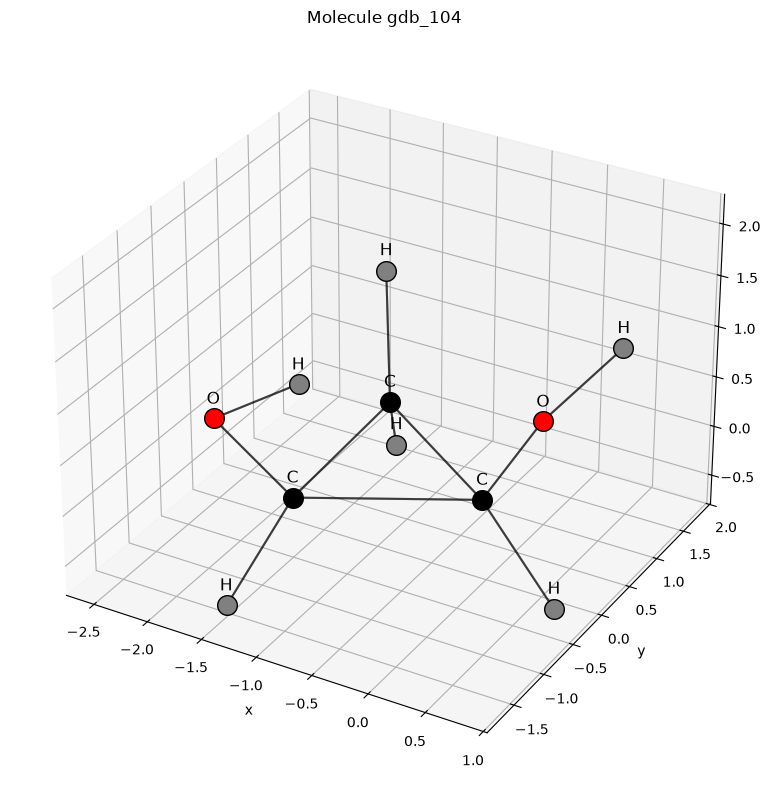

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

colors = {1:'gray', 6:'black', 7:'blue', 8:'red', 9:'green'}
labels = {1:'H', 6:'C', 7:'N', 8:'O', 9:'F'}

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

pos = g.pos.numpy()
z = g.z.tolist()
ei = g.edge_index.numpy()

# Draw bonds
for j in range(ei.shape[1]):
    i0, i1 = ei[0,j], ei[1,j]
    ax.plot([pos[i0,0], pos[i1,0]], [pos[i0,1], pos[i1,1]], [pos[i0,2], pos[i1,2]], 'k-', alpha=0.5)

# Draw atoms
for i in range(len(pos)):
    ax.scatter(pos[i,0], pos[i,1], pos[i,2], c=colors[z[i]], s=200, edgecolors='black')
    ax.text(pos[i,0], pos[i,1], pos[i,2]+0.15, labels[z[i]], fontsize=12, ha='center')

ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
plt.title(f'Molecule {g.name}')
plt.tight_layout()
plt.show()


wow what next for training?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

You've got a solid understanding of the data now! Before jumping into training, here's the roadmap:

1. **Build the EGNN model** — implement the EGCL layer from the paper (equations 3-6), stack 7 of them, add edge inference and the output MLP
2. **Prepare the data** — normalize targets (subtract mean, divide by MAD), create train/val/test splits (100K/18K/13K)
3. **Training loop** — one model per property, 1000 epochs, Adam, cosine LR, batch size 96
4. **Evaluation** — report MAE per target, compare against the paper's Table 3

Want to start with building the EGNN model from scratch, or would you rather find an existing implementation to work from?

are you able to see my .py files?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;fd(&#x27;.&#x27;, ext=&#x27;py&#x27;)&quot;)→&quot;[&#x27;src/data.py&#x27;]&quot;</code></summary>

```json
{
  "id": "chatcmpl-tool-86535c39ea155ec9",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "fd('.', ext='py')"
    }
  },
  "result": "['src/data.py']"
}
```

</details>

Yes! I can see `src/data.py` in your current folder. Want me to take a look at what's in it?

yes, this wil be our first exercise i guess

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

<details class='tool-usage-details' markdown='1'>
<summary><code>python(code=&quot;file_view(&#x27;src/data.py&#x27;)&quot;)→&quot;1: \&quot;\&quot;\&quot;QM9 data + the shared, determinist…&quot;</code></summary>

```json
{
  "id": "chatcmpl-tool-a2042c187a3bce8a",
  "server": false,
  "call": {
    "function": "python",
    "arguments": {
      "code": "file_view('src/data.py')"
    }
  },
  "result": "1: \"\"\"QM9 data + the shared, deterministic split for EGNN.  [SCAFFOLD — you fill bodies]\n2: \n3: Contract to match (same as template `data.py`):\n4:   ONE seeded split, imported by both train.py and evaluate.py so they always\n5:   agree on train/val/test — no leakage. Target normalization stats come from the\n6:   TRAIN split only and are returned, so train/evaluate normalize identically.\n7: \n8: Backend: torch_geometric.datasets.QM9 (small molecules, 3D coords, 19 targets).\n9: NOTE: torch_geometric is not yet a project dependency. Add it before running:\n10:     uv add torch_geometric\n11: \n12: Paper: Satorras et al., \"E(n) Equivariant Graph Neural Networks\", ICML 2021.\n13: Standard split: 100K train / 18K val / 13K test.\n14: \n15: ------------------------------------------------------------------------------\n16: WHAT YOU NEED TO BUILD (in rough order):\n17:   1. NormStats.normalize / denormalize        — the (y-mean)/std transform\n18:   2. load_split:\n19:        a. load QM9(root)\n20:        b. deterministic permutation w/ an EXPLICIT generator (not global RNG)\n21:        c. slice into 100K / 18K / 13K\n22:        d. compute NormStats on TRAIN targets only  (think: which column? why train-only?)\n23:        e. wrap each split in a PyG DataLoader\n24:        f. return (train, val, test, norm, dims)\n25: \n26: Questions worth answering as you go (this is the point of the exercise):\n27:   - Why must the split use an explicit generator, not torch.manual_seed?\n28:   - Why is normalization fit on train only — what leaks if you use the full set?\n29:   - QM9 y has 19 columns. Which index is your target? Verify against PyG docs.\n30:   - Where should edge construction live — here, or in the model? Why?\n31: ------------------------------------------------------------------------------\n32: \"\"\"\n33: \n34: from __future__ import annotations\n35: \n36: from dataclasses import dataclass\n37: \n38: import torch\n39: \n40: # torch_geometric is optional-at-import so the file is inspectable without the\n41: # dep installed. The actual functions require it.\n42: try:\n43:     from torch_geometric.datasets import QM9\n44:     from torch_geometric.loader import DataLoader as PyGDataLoader\n45: \n46:     _HAS_PYG = True\n47: except ImportError:  # pragma: no cover - dep not installed yet\n48:     QM9 = None\n49:     PyGDataLoader = None\n50:     _HAS_PYG = False\n51: \n52: \n53: # QM9 target columns in torch_geometric's `data.y` (shape [1, 19]).\n54: # Reference table — VERIFY these indices against the PyG QM9 docs before trusting.\n55: # Only the properties EGNN benchmarks (Table 1) are listed.\n56: QM9_TARGETS: dict[str, int] = {\n57:     \"mu\": 0,  # dipole moment (D)\n58:     \"alpha\": 1,  # isotropic polarizability (a0^3)\n59:     \"homo\": 2,  # HOMO (eV)\n60:     \"lumo\": 3,  # LUMO (eV)\n61:     \"gap\": 4,  # HOMO-LUMO gap (eV)\n62:     \"U0\": 7,  # internal energy at 0K (eV)\n63:     \"Cv\": 11,  # heat capacity (cal/mol/K)\n64: }\n65: \n66: # Standard QM9 split sizes (Satorras et al.).\n67: N_TRAIN = 100_000\n68: N_VAL = 18_000\n69: \n70: \n71: @dataclass\n72: class NormStats:\n73:     \"\"\"Train-set target normalization: subtract mean, divide by std.\"\"\"\n74: \n75:     mean: float\n76:     std: float\n77: \n78:     def normalize(self, y: torch.Tensor) -> torch.Tensor:\n79:         raise NotImplementedError(\"TODO: (y - mean) / std\")\n80: \n81:     def denormalize(self, y: torch.Tensor) -> torch.Tensor:\n82:         raise NotImplementedError(\"TODO: inverse of normalize\")\n83: \n84: \n85: def _require_pyg() -> None:\n86:     if not _HAS_PYG:\n87:         raise ImportError(\n88:             \"torch_geometric is required for QM9. Install it with: uv add torch_geometric\"\n89:         )\n90: \n91: \n92: def load_split(\n93:     target: str = \"gap\",\n94:     root: str = \"data/qm9\",\n95:     seed: int = 42,\n96:     batch_size: int = 96,\n97: ):\n98:     \"\"\"Return (train_loader, val_loader, test_loader, norm, dims).\n99: \n100:     dims: dict with `in_node_dim` (atom one-hot width) and `out_dim` (=1), so the\n101:     model never hardcodes shapes. norm: NormStats fit on the TRAIN split.\n102:     \"\"\"\n103:     _require_pyg()\n104:     if target not in QM9_TARGETS:\n105:         raise KeyError(f\"unknown target {target!r}; choose from {sorted(QM9_TARGETS)}\")\n106:     col = QM9_TARGETS[target]\n107: \n108:     # TODO a: dataset = QM9(root=rootht)\n109:     # TODO b: deterministic perm with an EXPLICIT torch.Generator().manual_seed(seed)\n110:     # TODO c: slice perm -> train_idx / val_idx / test_idx (use N_TRAIN, N_VAL)\n111:     # TODO d: fit NormStats on train targets at column `col` (train ONLY)\n112:     # TODO e: wrap each split in PyGDataLoader (shuffle train, not val/test)\n113:     # TODO f: build dims = {\"in_node_dim\": ..., \"out_dim\": 1}\n114:     raise NotImplementedError(\"TODO: implement the QM9 load + split + normalize\")"
}
```

</details>

Nice scaffold! This is a well-structured exercise. Here's what you need to fill in:

**1. `NormStats.normalize` and `denormalize`** (lines 78-82) — straightforward math:
- `normalize`: $(y - \text{mean}) / \text{std}$
- `denormalize`: $y \cdot \text{std} + \text{mean}$

**2. `load_split`** (lines 92-114) — 6 steps:
- Load QM9 dataset
- Create a deterministic shuffle using an explicit `torch.Generator` (not global RNG)
- Slice into 100K / 18K / 13K
- Compute mean & std from **train targets only** at the target column index
- Wrap each split in a `PyGDataLoader`
- Return the loaders, NormStats, and dims

**Things to note:**
- The `QM9_TARGETS` dict is incomplete — it only has 7 of the 12 targets. You'll need to add the missing 5 (r2, zpve, U, H, G) at indices 5, 6, 8, 9, 10
- The paper says normalization uses **MAD** (mean absolute deviation), not std — but the scaffold says std. Worth deciding which to follow
- Line 108 has a typo: `rootht` should be `root`

Want to start filling these in one at a time?

ya show me the  code in data.py ill try to answer each TODO and at the end you can evaluate and we can push it to .py

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Sounds like a great plan! Let's go one TODO at a time.

**First up: `NormStats.normalize` and `denormalize`** (lines 78-82).

These are the simplest — just replace the `raise NotImplementedError` lines. Based on the docstring, normalize does $(y - \text{mean}) / \text{std}$ and denormalize is the inverse.

Give it a shot — what would you write for those two methods?

show the full data.py context bro

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Here's the full file:

```python
"""QM9 data + the shared, deterministic split for EGNN.  [SCAFFOLD — you fill bodies]

Contract to match (same as template `data.py`):
  ONE seeded split, imported by both train.py and evaluate.py so they always
  agree on train/val/test — no leakage. Target normalization stats come from the
  TRAIN split only and are returned, so train/evaluate normalize identically.

Backend: torch_geometric.datasets.QM9 (small molecules, 3D coords, 19 targets).
NOTE: torch_geometric is not yet a project dependency. Add it before running:
    uv add torch_geometric

Paper: Satorras et al., "E(n) Equivariant Graph Neural Networks", ICML 2021.
Standard split: 100K train / 18K val / 13K test.

------------------------------------------------------------------------------
WHAT YOU NEED TO BUILD (in rough order):
  1. NormStats.normalize / denormalize        — the (y-mean)/std transform
  2. load_split:
       a. load QM9(root)
       b. deterministic permutation w/ an EXPLICIT generator (not global RNG)
       c. slice into 100K / 18K / 13K
       d. compute NormStats on TRAIN targets only  (think: which column? why train-only?)
       e. wrap each split in a PyG DataLoader
       f. return (train, val, test, norm, dims)

Questions worth answering as you go (this is the point of the exercise):
  - Why must the split use an explicit generator, not torch.manual_seed?
  - Why is normalization fit on train only — what leaks if you use the full set?
  - QM9 y has 19 columns. Which index is your target? Verify against PyG docs.
  - Where should edge construction live — here, or in the model? Why?
------------------------------------------------------------------------------
"""

from __future__ import annotations

from dataclasses import dataclass

import torch

# torch_geometric is optional-at-import so the file is inspectable without the
# dep installed. The actual functions require it.
try:
    from torch_geometric.datasets import QM9
    from torch_geometric.loader import DataLoader as PyGDataLoader

    _HAS_PYG = True
except ImportError:  # pragma: no cover - dep not installed yet
    QM9 = None
    PyGDataLoader = None
    _HAS_PYG = False


# QM9 target columns in torch_geometric's `data.y` (shape [1, 19]).
# Reference table — VERIFY these indices against the PyG docs before trusting.
# Only the properties EGNN benchmarks (Table 1) are listed.
QM9_TARGETS: dict[str, int] = {
    "mu": 0,  # dipole moment (D)
    "alpha": 1,  # isotropic polarizability (a0^3)
    "homo": 2,  # HOMO (eV)
    "lumo": 3,  # LUMO (eV)
    "gap": 4,  # HOMO-LUMO gap (eV)
    "U0": 7,  # internal energy at 0K (eV)
    "Cv": 11,  # heat capacity (cal/mol/K)
}

# Standard QM9 split sizes (Satorras et al.).
N_TRAIN = 100_000
N_VAL = 18_000


@dataclass
class NormStats:
    """Train-set target normalization: subtract mean, divide by std."""

    mean: float
    std: float

    def normalize(self, y: torch.Tensor) -> torch.Tensor:
        raise NotImplementedError("TODO: (y - mean) / std")

    def denormalize(self, y: torch.Tensor) -> torch.Tensor:
        raise NotImplementedError("TODO: inverse of normalize")


def _require_pyg() -> None:
    if not _HAS_PYG:
        raise ImportError(
            "torch_geometric is required for QM9. Install it with: uv add torch_geometric"
        )


def load_split(
    target: str = "gap",
    root: str = "data/qm9",
    seed: int = 42,
    batch_size: int = 96,
):
    """Return (train_loader, val_loader, test_loader, norm, dims).

    dims: dict with `in_node_dim` (atom one-hot width) and `out_dim` (=1), so the
    model never hardcodes shapes. norm: NormStats fit on the TRAIN split.
    """
    _require_pyg()
    if target not in QM9_TARGETS:
        raise KeyError(f"unknown target {target!r}; choose from {sorted(QM9_TARGETS)}")
    col = QM9_TARGETS[target]

    # TODO a: dataset = QM9(root=rootht)
    # TODO b: deterministic perm with an EXPLICIT torch.Generator().manual_seed(seed)
    # TODO c: slice perm -> train_idx / val_idx / test_idx (use N_TRAIN, N_VAL)
    # TODO d: fit NormStats on train targets at column `col` (train ONLY)
    # TODO e: wrap each split in PyGDataLoader (shuffle train, not val/test)
    # TODO f: build dims = {"in_node_dim": ..., "out_dim": 1}
    raise NotImplementedError("TODO: implement the QM9 load + split + normalize")
```

Start with `NormStats.normalize` and `denormalize` — what would you write?